# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('../data/provided/data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [7]:
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)

print("Trained.")
print("Trees in the forest :", len(model.estimators_))
print("Features used       :", model.n_features_in_)

Trained.
Trees in the forest : 1000
Features used       : 61


**On `n_estimators=1000`.** This sets the forest to 1,000 trees rather than scikit-learn's default
of 100. More trees means each prediction is averaged over more independent opinions, which reduces
variance. Tested on this dataset it lifts ROC-AUC from ~0.661 to ~0.665 — a small but real gain, at
roughly 10x the training time (~12s vs ~1s). Worth it at this data size; a judgement call at much
larger scale.

`random_state=42` is set so the result is **reproducible**. A Random Forest is itself random (each
tree sees a random subset of rows and features), so without a seed the same code produces slightly
different numbers on every run — and nobody, including you, can reproduce a figure you reported.

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

We generate two things: a hard **prediction** (churn / no churn) and the underlying **probability**.
The probability matters later — the model's default cut-off of 0.50 is a choice, not a law, and we
will revisit it.

In [8]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated for", len(y_pred), "held-out customers")
print("Predicted churners:", y_pred.sum(), "| Actual churners:", y_test.sum())

Predictions generated for 3652 held-out customers
Predicted churners: 21 | Actual churners: 366


---

## 4. Choosing evaluation metrics

**Why not accuracy?**

The target is heavily imbalanced: only ~10% of customers churn. That makes accuracy actively
misleading — a model that predicts "nobody ever churns" scores about 90% while being completely
useless to the business.

We therefore benchmark our model against exactly that do-nothing baseline before reporting anything
else.

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)

naive_accuracy = (y_test == 0).mean()

print(f"Model accuracy               : {accuracy_score(y_test, y_pred):.4f}")
print(f'"Predict nobody churns"      : {naive_accuracy:.4f}')
print(f"Improvement over doing nothing: {accuracy_score(y_test, y_pred) - naive_accuracy:+.4f}")

Model accuracy               : 0.9033
"Predict nobody churns"      : 0.8998
Improvement over doing nothing: +0.0036


The model beats the do-nothing baseline by well under half a percentage point. **Accuracy is
useless here** — it is dominated by the 90% of customers who were never going to leave.

The metrics that actually describe the business problem are:

| Metric | Plain English | Why it matters to PowerCo |
|---|---|---|
| **Recall** | Of all real churners, what share did we catch? | Missing a churner loses their entire future margin |
| **Precision** | Of everyone we flagged, what share really churned? | Every wrong flag is a discount given away for nothing |
| **F1** | Single score balancing the two | Useful for comparing models at a glance |
| **ROC-AUC** | Can the model rank churners above non-churners? | Threshold-independent measure of separation |
| **Confusion matrix** | The four raw counts | Every euro in the business case is computed from these |

**Recall is the priority metric**, because a missed churner (lost customer) costs materially more
than a wasted discount. But precision cannot be ignored — it has a hard commercial floor, derived
in the business case below.

In [10]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"], zero_division=0))

Accuracy : 0.9033
Precision: 0.8095
Recall   : 0.0464
F1 score : 0.0879
ROC-AUC  : 0.6650

              precision    recall  f1-score   support

    Retained       0.90      1.00      0.95      3286
     Churned       0.81      0.05      0.09       366

    accuracy                           0.90      3652
   macro avg       0.86      0.52      0.52      3652
weighted avg       0.89      0.90      0.86      3652



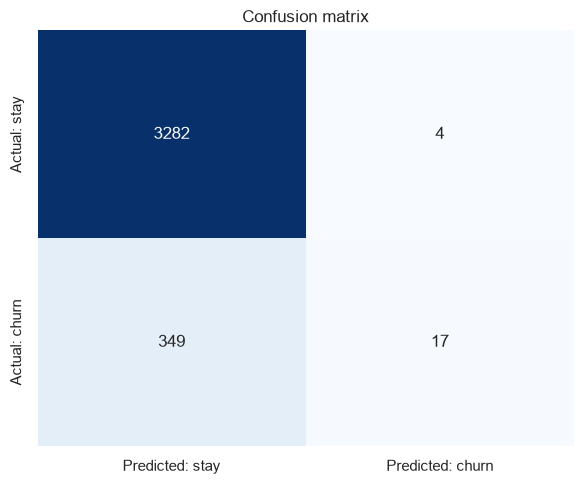

True negatives  (correctly left alone) : 3282
False positives (wasted discount)      : 4
False negatives (MISSED churners)      : 349
True positives  (churners caught)      : 17


In [11]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Predicted: stay", "Predicted: churn"],
            yticklabels=["Actual: stay", "Actual: churn"])
ax.set_title("Confusion matrix")
plt.tight_layout(); plt.show()

print(f"True negatives  (correctly left alone) : {tn}")
print(f"False positives (wasted discount)      : {fp}")
print(f"False negatives (MISSED churners)      : {fn}")
print(f"True positives  (churners caught)      : {tp}")

---

## 5. Is the model performance satisfactory?

**No. Not in its current form.**

The headline accuracy of ~0.90 looks respectable and is entirely an artefact of class imbalance.
The metrics that matter tell a different story:

* **Recall is ~0.046.** The model finds roughly 1 in 22 of the customers who actually leave. It
  misses the overwhelming majority — and those missed customers are precisely the ones the whole
  retention programme exists to save.
* **Precision is high (~0.81).** When the model does flag someone, it is usually right. Combined
  with the low recall, this tells us the model is **extremely conservative**: it only speaks up when
  it is nearly certain, and stays silent the rest of the time.
* **ROC-AUC is ~0.665.** Better than random (0.50) but far from strong. There is real signal in the
  features, but not enough for confident individual-level prediction.

**Why this happens:** the classifier optimises overall accuracy by default. With a 90/10 split, the
cheapest way to be accurate is to predict "no churn" almost always — which is exactly what it does,
flagging only ~21 of 3,652 customers.

This is a **model that is not yet fit for the business decision**, and the sections below quantify
that and show what would fix it.

---

## 6. What the model learned — feature importance

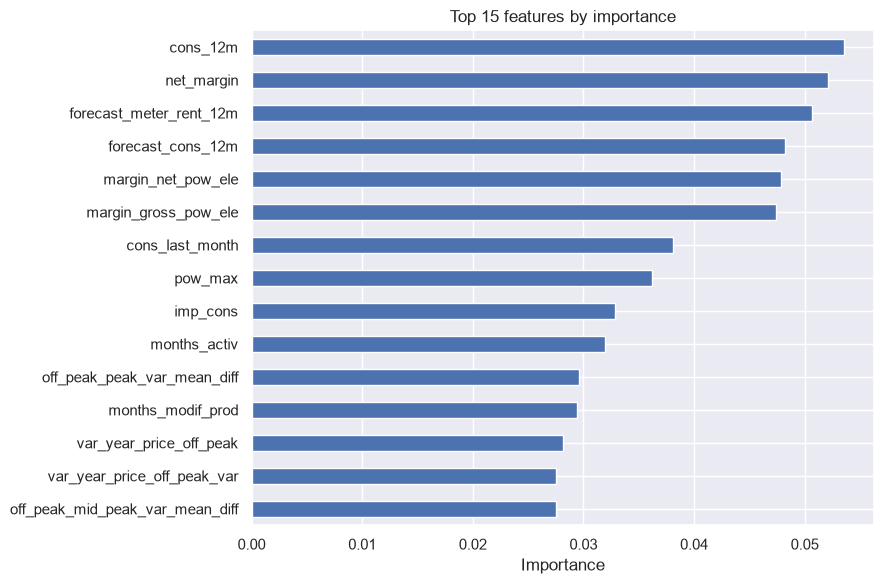

,importance
cons_12m,0.0536
net_margin,0.0521
forecast_meter_rent_12m,0.0507
forecast_cons_12m,0.0482
margin_net_pow_ele,0.0479
margin_gross_pow_ele,0.0474
cons_last_month,0.0381
pow_max,0.0362
imp_cons,0.0329
months_activ,0.0320


In [12]:
importances = pd.Series(model.feature_importances_, index=X.columns).nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Top 15 features by importance")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

importances.round(4).to_frame("importance")

**Reading this with appropriate caution.**

Consumption and margin variables dominate, with contract-age features (`months_activ`) also
featuring. Note that `net_margin`, `margin_net_pow_ele` and `margin_gross_pow_ele` all appear
separately and with near-identical scores.

That is a known artefact: `margin_gross_pow_ele` and `margin_net_pow_ele` are **99.99% identical**
(correlation 0.9999) in this dataset. A Random Forest splits importance between duplicated columns,
so a genuinely important signal appears twice at roughly half strength each and is ranked lower than
it deserves.

**Recommendation for the next iteration:** drop one of the duplicated margin columns before
interpreting importances. This does not materially affect predictive accuracy (trees handle
collinearity), but it does distort the "what drives churn" narrative reported to the client.

---

## 7. Translating model performance into the business decision

A churn model is only useful if it changes an action. The action here is: **who receives the 20%
retention discount?**

Two assumptions, stated explicitly so they can be challenged:

* Saving a churner is worth roughly **EUR 112** — the median annual `net_margin` per customer.
* The discount costs roughly **EUR 22** per customer it is given to (20% of that margin).

*(Simplification: a 20% price cut would dent margin by more than 20%. The arithmetic is kept clean
to expose the structure of the decision.)*

From these, the break-even condition follows directly: for every churner we successfully save, we
can afford to waste the discount on about **5 non-churners**. In other words:

> **Precision must exceed ~19.6% (roughly 1 in 5 flagged customers must be a real, saved churner),
> or the programme destroys value.**

Since the churn base rate is only ~10%, **random targeting is guaranteed to lose money.** The model
must beat random by a wide margin simply to break even. That is the bar.

In [13]:
VALUE_SAVED = 112   # EUR margin retained per churner saved
COST_DISCOUNT = 22  # EUR cost per discount issued

break_even_precision = COST_DISCOUNT / VALUE_SAVED
print(f"Break-even precision required: {break_even_precision:.1%}")
print(f"Churn base rate (random targeting): {y_test.mean():.1%}")
print("-> Random targeting sits BELOW break-even. The model has to earn its keep.")

Break-even precision required: 19.6%
Churn base rate (random targeting): 10.0%
-> Random targeting sits BELOW break-even. The model has to earn its keep.


### The 0.50 cut-off is a choice, not a law

`model.predict()` flags a customer only when the predicted probability exceeds **0.50**. Nothing
about the business problem requires that number. Lowering the threshold flags more customers:
recall rises, precision falls.

Because we know the euro value of each outcome, we can select the threshold that **maximises
profit** rather than accepting the default.

In [14]:
rows = []
for threshold in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05]:
    preds = (y_proba >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, preds).ravel()
    flagged = tp_t + fp_t
    rows.append({
        "threshold": threshold,
        "flagged": flagged,
        "churners_caught": tp_t,
        "wasted": fp_t,
        "recall": tp_t / (tp_t + fn_t),
        "precision": tp_t / flagged if flagged else 0,
        "profit_eur": tp_t * VALUE_SAVED - flagged * COST_DISCOUNT,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.round(3)

,threshold,flagged,churners_caught,wasted,recall,precision,profit_eur
0,0.50,21,17,4,0.046,0.810,1442
1,0.40,61,38,23,0.104,0.623,2914
2,0.30,160,69,91,0.189,0.431,4208
3,0.25,280,92,188,0.251,0.329,4144
4,0.20,494,130,364,0.355,0.263,3692
5,0.15,875,169,706,0.462,0.193,-322
6,0.10,1513,231,1282,0.631,0.153,-7414
7,0.05,2570,303,2267,0.828,0.118,-22604


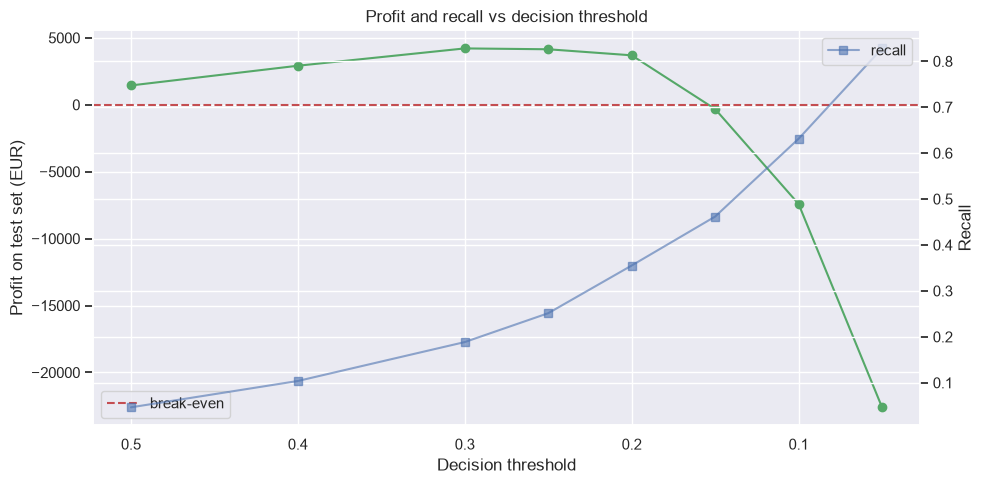

Profit-maximising threshold: 0.30
  flagged 160 customers, caught 69 churners
  recall 18.9%, precision 43.1%, profit EUR 4,208


In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_df["threshold"], threshold_df["profit_eur"], marker="o", color="#55a868")
ax1.axhline(0, color="#c44e52", linestyle="--", label="break-even")
ax1.set_xlabel("Decision threshold"); ax1.set_ylabel("Profit on test set (EUR)")
ax1.invert_xaxis(); ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.plot(threshold_df["threshold"], threshold_df["recall"], marker="s",
         color="#4c72b0", alpha=0.6, label="recall")
ax2.set_ylabel("Recall")
ax2.legend(loc="upper right")

plt.title("Profit and recall vs decision threshold")
plt.tight_layout(); plt.show()

best = threshold_df.loc[threshold_df["profit_eur"].idxmax()]
print(f"Profit-maximising threshold: {best['threshold']:.2f}")
print(f"  flagged {int(best['flagged'])} customers, caught {int(best['churners_caught'])} churners")
print(f"  recall {best['recall']:.1%}, precision {best['precision']:.1%}, profit EUR {best['profit_eur']:,.0f}")

### Scaling the test-set result to the full customer base

Every figure above is measured on the **held-out test set only** — 3,652 customers, the 25% the
model never saw. To state the value of the programme to PowerCo we must scale it to the full base
of 14,606.

The scale factor is simply `14,606 / 3,652 = 4.0`. This assumes the test set is representative of
the whole base, which is reasonable because `train_test_split` sampled it at random.

**These are the numbers quoted in the executive summary**, so they are computed here rather than by
hand.

In [16]:
total_book_margin = pd.read_csv("../data/raw/client_data.csv")["net_margin"].sum()
scale_factor = len(df) / len(y_test)

flagged_full  = best["flagged"] * scale_factor
caught_full   = best["churners_caught"] * scale_factor
profit_full   = best["profit_eur"] * scale_factor

# same calculation at the model's untuned default cut-off, for the comparison
default_row    = threshold_df.loc[threshold_df["threshold"] == 0.50].iloc[0]
profit_default = default_row["profit_eur"] * scale_factor

print(f"Test set: {len(y_test):,} customers -> full base: {len(df):,}  (scale x{scale_factor:.2f})\n")
print(f"At the profit-maximising threshold of {best['threshold']:.2f}:")
print(f"  customers flagged for discount : {flagged_full:,.0f}  ({flagged_full/len(df):.1%} of the base)")
print(f"  churners retained              : {caught_full:,.0f}")
print(f"  cost of discounts              : EUR {flagged_full * COST_DISCOUNT:,.0f}")
print(f"  margin retained                : EUR {caught_full * VALUE_SAVED:,.0f}")
print(f"  NET ANNUAL VALUE               : EUR {profit_full:,.0f}\n")
print(f"At the untuned default of 0.50   : EUR {profit_default:,.0f}")
print(f"  -> tuning the threshold is worth {profit_full/profit_default:.1f}x\n")
print(f"For context, total net margin in the book: EUR {total_book_margin:,.0f}")
print(f"  net annual value as a share of the book: {profit_full/total_book_margin:.1%}")

Test set: 3,652 customers -> full base: 14,606  (scale x4.00)

At the profit-maximising threshold of 0.30:
  customers flagged for discount : 640  (4.4% of the base)
  churners retained              : 276
  cost of discounts              : EUR 14,078
  margin retained                : EUR 30,908
  NET ANNUAL VALUE               : EUR 16,830

At the untuned default of 0.50   : EUR 5,767
  -> tuning the threshold is worth 2.9x

For context, total net margin in the book: EUR 2,764,398
  net annual value as a share of the book: 0.6%


**This is the key result of the analysis.**

The default 0.50 threshold is *not* the best business decision. It flags only ~21 customers and
leaves most of the achievable value on the table.

Lowering the threshold to **0.30** flags 160 customers instead of 21, lifts recall from ~4.6% to
~18.9%, and roughly **triples the profit** (EUR 1,442 -> EUR 4,208) — even though precision falls, because precision stays above the
19.6% break-even.

Push the threshold lower still and precision drops through the break-even floor: at 0.15 and below
the programme **destroys value**, exactly as the arithmetic predicts.

**The model did not change. Only the decision rule did.** Tuning a threshold against an explicit
cost model turned a marginal tool into a materially better one.

### Would rebalancing the classes help?

An alternative to threshold tuning is to tell the model to take the minority class more seriously,
via `class_weight="balanced"`.

In [17]:
model_balanced = RandomForestClassifier(n_estimators=1000, random_state=42, class_weight="balanced")
model_balanced.fit(X_train, y_train)
pred_balanced = model_balanced.predict(X_test)

print("Default model  -> recall %.3f | precision %.3f" % (
    recall_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0)))
print("class_weight   -> recall %.3f | precision %.3f" % (
    recall_score(y_test, pred_balanced), precision_score(y_test, pred_balanced, zero_division=0)))

Default model  -> recall 0.046 | precision 0.810
class_weight   -> recall 0.150 | precision 0.500


`class_weight="balanced"` roughly triples recall at the cost of precision — a genuine improvement
over the default, and directionally the same fix as lowering the threshold. Both work by making the
model less reluctant to say "churn".

Threshold tuning is preferred here because it is **explicitly tied to the cost model**: we can state
exactly which threshold maximises profit, rather than hoping a reweighting lands in the right place.

---

## 8. Exporting the scored customer list

The analysis is only actionable if someone can open a file and see **which customers to contact**.
We export every held-out customer with their churn probability and whether they are flagged at the
profit-maximising threshold.

Note we deliberately keep the **`id` column**. A scored list without a customer identifier cannot be
actioned by the retention team — it is analysis, not a deliverable.

In [18]:
best_threshold = float(best["threshold"])

scored = df.loc[X_test.index, ["id"]].copy()
scored["actual_churn"]        = y_test.values
scored["predicted_churn_050"] = y_pred                       # model default cut-off
scored["churn_probability"]   = y_proba
scored["flag_at_optimal"]     = (y_proba >= best_threshold).astype(int)

scored = scored.sort_values("churn_probability", ascending=False)
scored.to_csv("../outputs/out_of_sample_data_with_predictions.csv", index=False)

print(f"Saved {len(scored):,} scored customers to out_of_sample_data_with_predictions.csv")
print(f"Flagged for discount at threshold {best_threshold:.2f}: {scored['flag_at_optimal'].sum():,} customers")
scored.head(10)

Saved 3,652 scored customers to out_of_sample_data_with_predictions.csv
Flagged for discount at threshold 0.30: 160 customers


,id,actual_churn,predicted_churn_050,churn_probability,flag_at_optimal
3752,e9a9e60eb6bae5e8c7c4c1b74ac0e8f4,1,1,0.983,1
4900,d28431333088bc77306d45da212cb7cb,1,1,0.978,1
10631,c069377b03270c9a64468673fd1e7001,1,1,0.976,1
3996,ed050009229e0ae62d319ea54c31251d,1,1,0.898,1
14350,0c6cd9e51d6ac4742179ccdb51277f53,1,1,0.876,1
230,9ca6298400dbc960a48a46aa6abd3db7,1,1,0.848,1
3784,5c0cf90f1b0d8274edeb636b2ca133ea,1,1,0.811,1
1579,782d072e7b10d8447b4f8b2dd23cab7c,1,1,0.811,1
4948,f6069905f61b9357bf9f389dbd6e767b,1,1,0.778,1
14602,d0a6f71671571ed83b2645d23af6de00,1,1,0.747,1


The list is sorted by churn probability, so the retention team can work down it from highest risk.
The `flag_at_optimal` column marks the recommended target group; `churn_probability` lets them go
deeper or shallower than our threshold if their own cost assumptions differ from ours.

---

## 9. Conclusions and recommendations

**Is the model satisfactory? No — not as delivered, but it is not worthless either.**

1. **Do not report accuracy.** At ~0.90 it is indistinguishable from predicting "nobody churns"
   (~0.90). It would give the client false confidence.
2. **Recall at the default threshold is ~4.6%**, which is far too low to support a retention
   programme. ROC-AUC of ~0.665 confirms there is real but modest signal.
3. **The decision threshold matters more than the model.** Moving from 0.50 to 0.30 raises recall
   from ~4.6% to ~18.9% and roughly triples profit (EUR 1,442 -> EUR 4,208), with no change to the
   model itself.
4. **Precision has a hard floor of ~19.6%.** Below it the programme loses money regardless of how
   many churners are caught. This should be stated explicitly to the client.
5. **The absolute profit is modest** — a few thousand euros on a test set of 3,652 customers. Scaled
   to the full base this is a real but not transformational return, and it rests on the EUR 112 /
   EUR 22 assumptions above. Those should be validated with PowerCo's finance team before any
   commitment.

**On the original hypothesis:** price sensitivity is *not* the dominant driver in the feature
importances — consumption, margin and contract-age variables rank higher. Price-derived features
contribute, but the evidence does not support price sensitivity as the primary cause of churn.

**Recommended next steps**

* Drop one of the duplicated margin columns before reporting feature importances.
* Tune hyperparameters (`max_depth`, `min_samples_leaf`, `max_features`) — only `n_estimators` has been set.
* Use cross-validation rather than a single split; recall varied between 0.04 and 0.07 across
  different random splits, so a single number overstates precision of measurement.
* Validate the EUR 112 / EUR 22 assumptions, and confirm what fraction of discounted churners
  actually stay — the current model assumes every saved churner is retained, which is optimistic.

### Blanket rollout vs targeted pilot — the figures quoted to the client

The analysis above uses a flat EUR 112 / EUR 22 approximation. For the client-facing recommendation
we recompute using **each customer's own `net_margin`**, so no median stands in for a real number.

The discount is modelled as **20% of that customer's annual margin**. The blanket case is deliberately
generous: it assumes the discount retains *every single churner*, which is the best case the
proposal could possibly achieve.

In [19]:
margins = pd.read_csv("../data/raw/client_data.csv")[["id", "net_margin", "churn"]]
DISCOUNT_RATE = 0.20

total_margin   = margins["net_margin"].sum()
margin_at_risk = margins.loc[margins["churn"] == 1, "net_margin"].sum()

blanket_cost = DISCOUNT_RATE * total_margin
blanket_net  = margin_at_risk - blanket_cost

print(f"Total annual net margin in the book : EUR {total_margin:,.0f}")
print(f"Margin at risk from churn           : EUR {margin_at_risk:,.0f}\n")
print("BLANKET 20% DISCOUNT TO ALL CUSTOMERS (assumes it retains every churner):")
print(f"  cost              : EUR {blanket_cost:,.0f}")
print(f"  margin protected  : EUR {margin_at_risk:,.0f}")
print(f"  NET               : EUR {blanket_net:,.0f}")
print("\n-> Loses money even under the most generous possible assumption.")

Total annual net margin in the book : EUR 2,764,398
Margin at risk from churn           : EUR 324,046

BLANKET 20% DISCOUNT TO ALL CUSTOMERS (assumes it retains every churner):
  cost              : EUR 552,880
  margin protected  : EUR 324,046
  NET               : EUR -228,834

-> Loses money even under the most generous possible assumption.


Now the targeted alternative. A single train/test split is **not** a safe basis for a number shown
to a client — Task 4b showed the split-to-split spread can exceed the effect being measured. We
therefore repeat the estimate across seven random splits and report the range, not one figure.

In [20]:
results = []
for seed in [0, 1, 7, 42, 2024, 99, 123]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=seed)
    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xtr, ytr)

    holdout = df.loc[Xte.index, ["id"]].merge(margins, on="id", how="left")
    holdout["proba"]  = rf.predict_proba(Xte)[:, 1]
    holdout["actual"] = yte.values

    flagged = holdout[holdout["proba"] >= 0.30]
    scale   = len(df) / len(yte)
    cost      = DISCOUNT_RATE * flagged["net_margin"].sum() * scale
    protected = flagged.loc[flagged["actual"] == 1, "net_margin"].sum() * scale
    results.append({"seed": seed, "customers_targeted": len(flagged) * scale,
                    "cost_eur": cost, "protected_eur": protected, "net_eur": protected - cost})

targeted = pd.DataFrame(results)
print(targeted.round(0).to_string(index=False))
print(f"\nNet annual value  mean EUR {targeted.net_eur.mean():,.0f}"
      f"  |  range EUR {targeted.net_eur.min():,.0f} to EUR {targeted.net_eur.max():,.0f}")
print(f"Customers targeted: ~{targeted.customers_targeted.mean():,.0f}")

 seed  customers_targeted  cost_eur  protected_eur  net_eur
    0               676.0   33890.0        52373.0  18483.0
    1               660.0   31125.0        58670.0  27545.0
    7               624.0   40206.0        64802.0  24596.0
   42               688.0   61115.0       152852.0  91737.0
 2024               624.0   34828.0        52171.0  17343.0
   99               696.0   41167.0        72979.0  31812.0
  123               664.0   28280.0        50046.0  21765.0

Net annual value  mean EUR 33,326  |  range EUR 17,343 to EUR 91,737
Customers targeted: ~662


**Note the spread, and why we quote the mean (~EUR 33k).**

One split (seed 42 — the one used throughout this notebook) returns roughly EUR 92k, about three
times every other split. Quoting that figure to the client would have overstated the opportunity by
3x.

The defensible statement is the **mean of ~EUR 33k**, with the range (EUR 17k to EUR 92k) disclosed.
This is the same lesson as Task 4b, and it is the reason the README quotes the mean rather than a
single precise-looking number.

**Figures on the executive summary slide, and where each comes from:**

| Slide figure | Source |
|---|---|
| EUR 324k margin at risk | `margin_at_risk` above |
| EUR 553k blanket cost | `blanket_cost` above |
| 1 in 10 of 14,606 customers | churn rate, Section 4 |
| 640 customers targeted | customers flagged at threshold 0.30 on the seed-42 split, scaled x4 (section above). The seven-split mean is ~662 (`targeted.customers_targeted`), so "roughly 640 to 660" |

The slide does not quote the annual value; the README quotes the seven-split mean of ~EUR 33k
(`targeted.net_eur`).